In [1]:
import sqlite3
import pandas as pd

In [2]:
# Connect to the SQLite database file
conn = sqlite3.connect('sqlite-sakila.db')

# Query to get all table names
query_table = "SELECT name from sqlite_master WHERE Type='table';"
table_names = pd.read_sql_query(query_table, conn)['name'].tolist()

print(f'Tables in database:\n {table_names}')

Tables in database:
 ['actor', 'country', 'city', 'address', 'language', 'category', 'customer', 'film', 'film_actor', 'film_category', 'film_text', 'inventory', 'staff', 'store', 'payment', 'rental']


In [3]:
# Create an empty dictionary to hold our DataFrames
dfs = {}

# Loop through each table name and load its data
for table in table_names:
    dfs[table] = pd.read_sql_query(f'Select * from {table}', conn)
    print(f'Read table {table}')

# It's good practice to close the connection when we're done
conn.close()

Read table actor
Read table country
Read table city
Read table address
Read table language
Read table category
Read table customer
Read table film
Read table film_actor
Read table film_category
Read table film_text
Read table inventory
Read table staff
Read table store
Read table payment
Read table rental


In [4]:
df_rental = dfs['rental']
df_customer = dfs['customer']
df_payment = dfs['payment']
df_inventory = dfs['inventory']
df_film = dfs['film']
df_category = dfs['category']
df_category_film = dfs['film_category']

In [5]:
# Convert the 'rental_date' column to datetime objects
df_rental['rental_only_date'] = pd.to_datetime(df_rental['rental_date'])

In [6]:
# Group by month and count the rentals
result = (
    df_rental
    .assign(month=df_rental['rental_only_date'].dt.strftime('%Y-%m'))
    .groupby('month', as_index=False)
    .size()
    .rename(columns={'size': 'rentals'})
    .sort_values('month')
)

print(result)

     month  rentals
0  2005-05     1156
1  2005-06     2311
2  2005-07     6709
3  2005-08     5686
4  2006-02      182


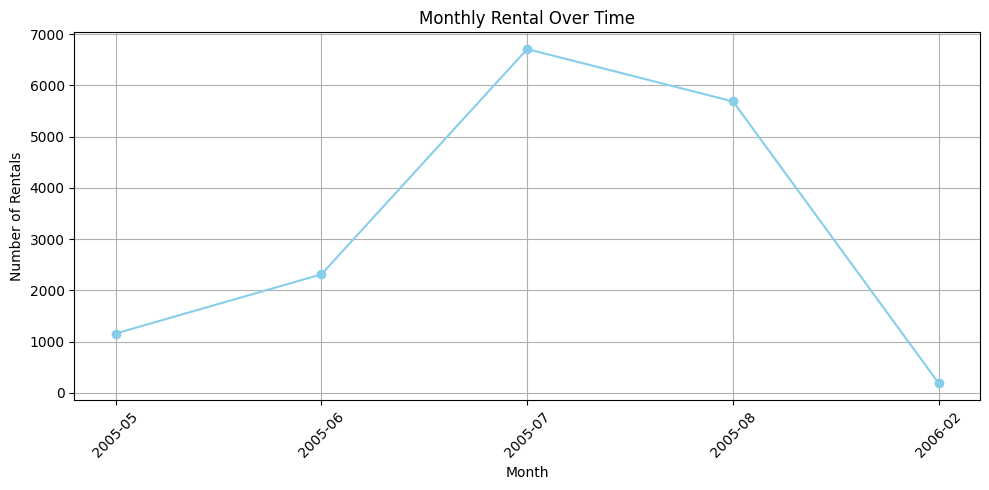

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5)) # Set the size of the plot
plt.plot(result['month'], result['rentals'], marker='o', color='skyblue') # Create the line plot
plt.title('Monthly Rental Over Time') # Add a title
plt.xlabel('Month') # Add x-axis label
plt.ylabel('Number of Rentals') # Add y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels to prevent overlap
plt.grid(True) # Add a grid for easier reading
plt.tight_layout() # Adjust plot to fit labels
plt.show() # Display the plot

In [8]:
# Merge rental, inventory, and film tables to link rentals to titles
merged = df_rental.merge(df_inventory, on='inventory_id', how='inner')
merged = merged.merge(df_film, on='film_id', how='inner')

In [9]:
# Group by film title, count rentals, sort, and take the top 10
top_10_films = (
    merged.groupby(['film_id', 'title'], as_index=False)
    .size()
    .rename(columns={'size': 'rentals'})
    .sort_values('rentals', ascending=False)
    .head(10)
)

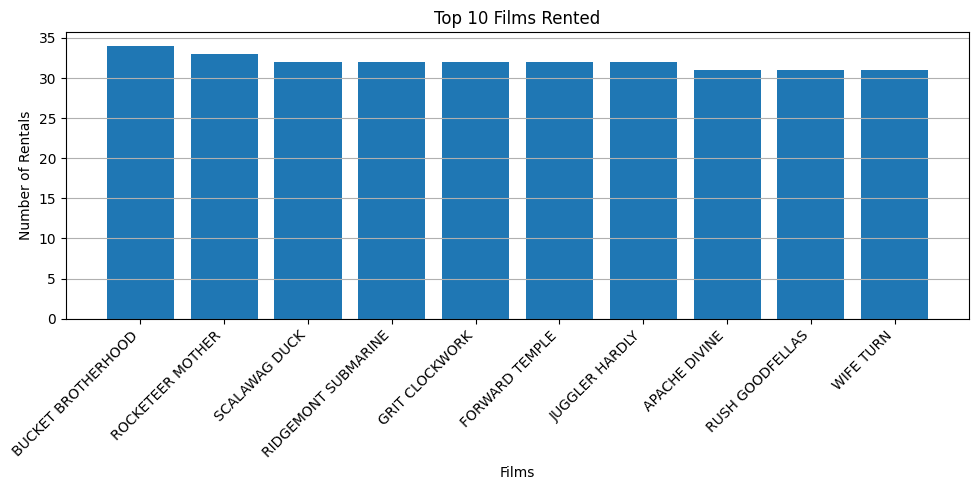

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(top_10_films['title'], top_10_films['rentals']) # Create the bar chart
plt.title('Top 10 Films Rented')
plt.xlabel('Films')
plt.ylabel('Number of Rentals')
plt.xticks(rotation=45, ha="right") # Rotate and align labels
plt.grid(axis='y') # Add a horizontal grid
plt.tight_layout()
plt.show()

In [13]:
category_rentals = (
    df_rental
    .merge(df_inventory.drop(columns=["last_update"]), on='inventory_id', how='inner')
    .merge(df_category_film.drop(columns=["last_update"]), on='film_id', how='inner')
    .merge(df_category.drop(columns=["last_update"]), on='category_id', how='inner')
    .groupby("name", as_index=False)
    .size()
    .rename(columns={"name": "category", "size": "rentals"})
    .sort_values("rentals", ascending=False)
)

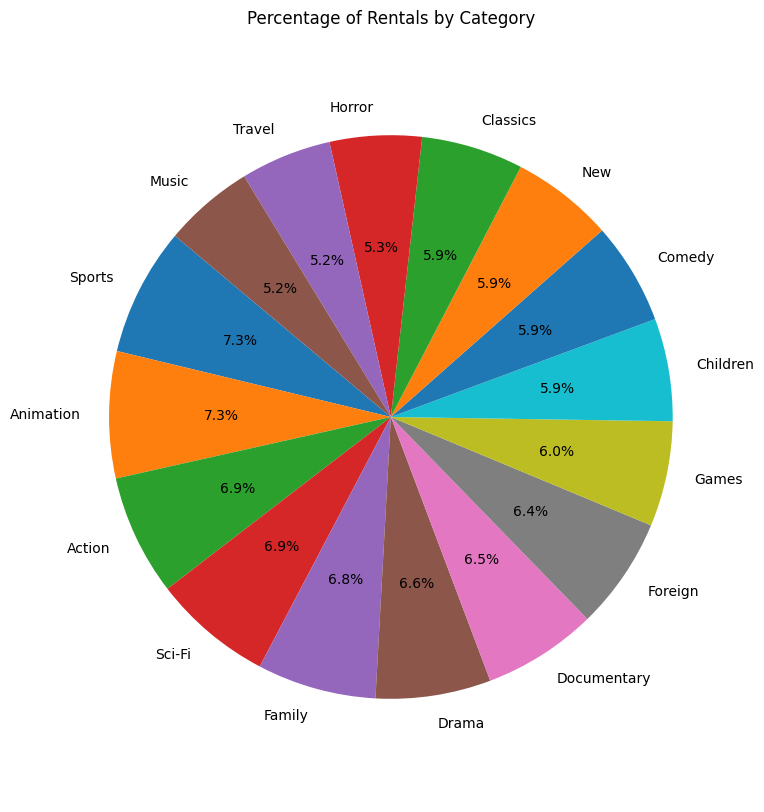

In [14]:
plt.figure(figsize=(8, 10))
plt.pie(
    category_rentals["rentals"],
    labels=category_rentals["category"],
    autopct="%1.1f%%", # Format to show one decimal place
    startangle=140
)
plt.title("Percentage of Rentals by Category")
plt.axis("equal") # Ensure the pie is circular
plt.show()

In [15]:
revenue_by_store = (
    df_payment
    .merge(df_rental[['rental_id', 'inventory_id']], on='rental_id', how='inner')
    .merge(df_inventory[['inventory_id', 'store_id']], on='inventory_id', how='inner')
    .groupby('store_id', as_index=False)['amount']
    .sum()
    .rename(columns={'amount': 'total_revenue'})
    .sort_values('store_id')
)

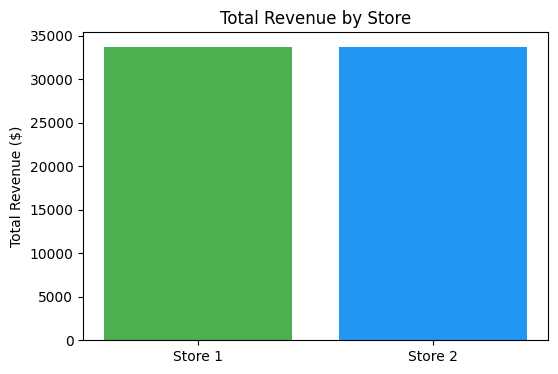

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(revenue_by_store['store_id'], revenue_by_store['total_revenue'], color=['#4CAF50', '#2196F3'])
# Use more descriptive labels for the x-axis ticks
plt.xticks(revenue_by_store['store_id'], [f"Store {sid}" for sid in revenue_by_store['store_id']])
plt.ylabel("Total Revenue ($)")
plt.title("Total Revenue by Store")
plt.show()


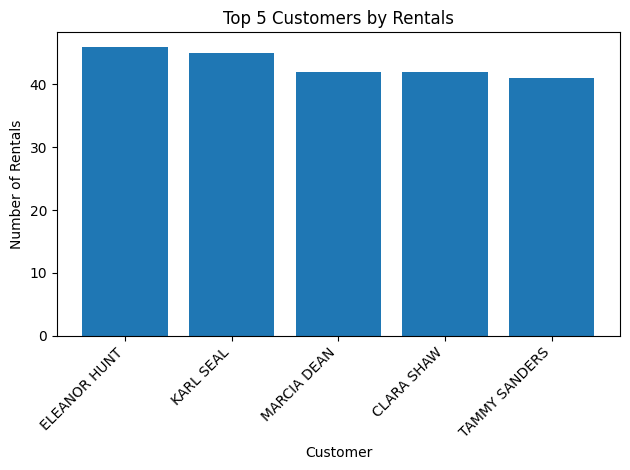

In [17]:
top_customers = (
    df_rental
    .groupby("customer_id")
    .size()
    .reset_index(name="rental_count")
    .merge(df_customer, on="customer_id", how="left")
    .sort_values("rental_count", ascending=False)
)

top_five = top_customers.head(5)

# Visualize the top 5
plt.bar(top_five["first_name"] + " " + top_five["last_name"], top_five["rental_count"])
plt.title("Top 5 Customers by Rentals")
plt.xlabel("Customer")
plt.ylabel("Number of Rentals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
